# Import Libraries

In [1]:
# Import basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Import NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Import Sklern Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Import Tensorflow Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.optimizers import AdamW

In [2]:
df = pd.read_csv(r'train.csv')

In [3]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
df.shape

(120000, 3)

In [5]:
df.columns

Index(['Class Index', 'Title', 'Description'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

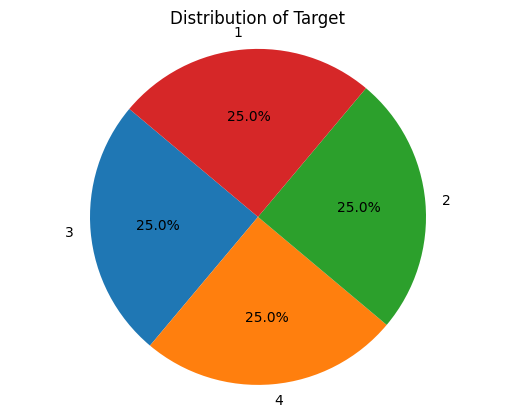

In [8]:
# Distribution of the Target column
dis = df['Class Index'].value_counts()

# Create a pie plot
plt.pie(
    x=dis,
    labels=dis.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Distribution of Target')
plt.axis('equal')
plt.show()

# Data Preprocessing

In [9]:
X = df['Title']+' '+df['Description']
y = df['Class Index']

In [10]:
X.head(2)

0    Wall St. Bears Claw Back Into the Black (Reute...
1    Carlyle Looks Toward Commercial Aerospace (Reu...
dtype: object

In [11]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [13]:
import re

def preprocess(text):
    # Lowercase
    text = str(text).lower()

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words with spaces
    return ' '.join(words)

X = X.apply(preprocess)

In [14]:
X.head(2)

0    wall st bear claw back black reuters reuters s...
1    carlyle look toward commercial aerospace reute...
dtype: object

In [15]:
X.shape

(120000,)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape,'\n')

# Now it's time to apply vectorizer
vector = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features= 10000,
    lowercase= True,
    min_df = 3,
    max_df = 0.95,
    sublinear_tf= True    
)

X_train = vector.fit_transform(X_train)
X_test = vector.transform(X_test)

print('X_train shape after vectorize:', X_train.shape)
print('X_test shape after vectoriz:', X_test.shape)

X_train shape: (96000,)
X_test shape: (24000,)
y_train shape: (96000,)
y_test shape: (24000,) 

X_train shape after vectorize: (96000, 10000)
X_test shape after vectoriz: (24000, 10000)


# Implement ANN

In [17]:
model = Sequential()

# Layer 1
model.add(Dense(256, use_bias=False, input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

# Layer 2
model.add(Dense(256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Layer 3
model.add(Dense(128, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

# Layer 4
model.add(Dense(128, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Layer 5
model.add(Dense(64, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

# Layer 6
model.add(Dense(64, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Output Layer
model.add(Dense(4, activation='softmax'))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           4,0

 Total params: 2,690,820 (10.26 MB)

 Trainable params: 2,689,028 (10.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [19]:
# Converts class labels from 1–4 to 0–3 because sparse_categorical_crossentropy requires zero-based class indices.
y_train = y_train - 1
y_test = y_test - 1

# Reduceing the Learnig Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor= 0.5,
    patience= 5,
    verbose = 0,
    min_lr= 1e-6    
)

# Update the optimizer
adamw = AdamW(
    learning_rate= 1e-3,
    weight_decay= 1e-4
)

# Using EarlyStopping to reduce overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta= 1e-4,
    patience= 5,
    verbose = 0,
    restore_best_weights= True
)

# Compile the model
model.compile(
    optimizer= adamw,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Now train the model
history = model.fit(
    X_train,
    y_train,
    epochs = 30,
    batch_size = 256,
    verbose = 1,
    callbacks = [reduce_lr, early_stop],
    validation_data = (X_test, y_test)
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.8296 - loss: 0.4737 - val_accuracy: 0.7848 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 89ms/step - accuracy: 0.9280 - loss: 0.2235 - val_accuracy: 0.9106 - val_loss: 0.2732 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.9460 - loss: 0.1638 - val_accuracy: 0.9119 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.9567 - loss: 0.1251 - val_accuracy: 0.9087 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.9664 - loss: 0.0961 - val_accuracy: 0.9087 - val_loss: 0.3503 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.9725 - loss: 0.0770 - val_accuracy: 0.9080 - val_loss: 0.4027 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - accuracy: 0.9765 - l

# Model Evaluation

In [20]:
loss, acu = model.evaluate(X_test, y_test,verbose=0)

print('Accuracy:', acu)

Accuracy: 0.9105833172798157


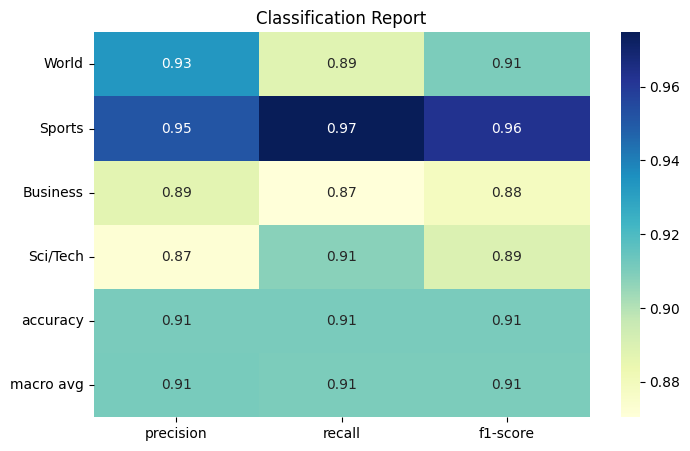

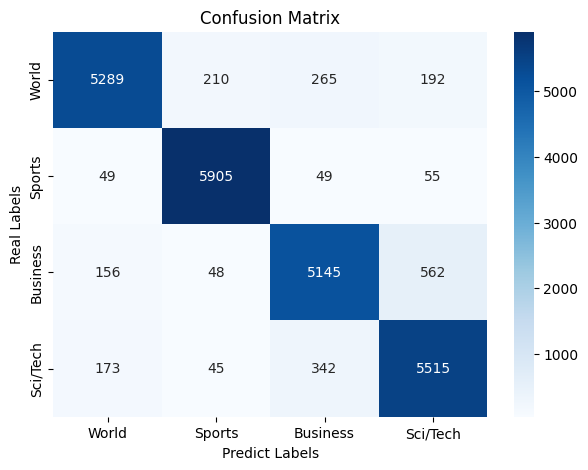

In [23]:
# Predict probabilities
y_pred = model.predict(X_test, verbose=0)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test  

class_names = ["World", "Sports", "Business", "Sci/Tech"]

# Classification report
report = classification_report(
    y_true,
    y_pred_classes,
    target_names= class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Classification Report")

plt.savefig("Classification_Report.png", dpi=500, bbox_inches="tight")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,5))

sns.heatmap(
    data = cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names
)

plt.title('Confusion Matrix')
plt.ylabel('Real Labels')
plt.xlabel('Predict Labels')

plt.savefig("Confusion_Matrix.png", dpi=500, bbox_inches="tight")
plt.show()

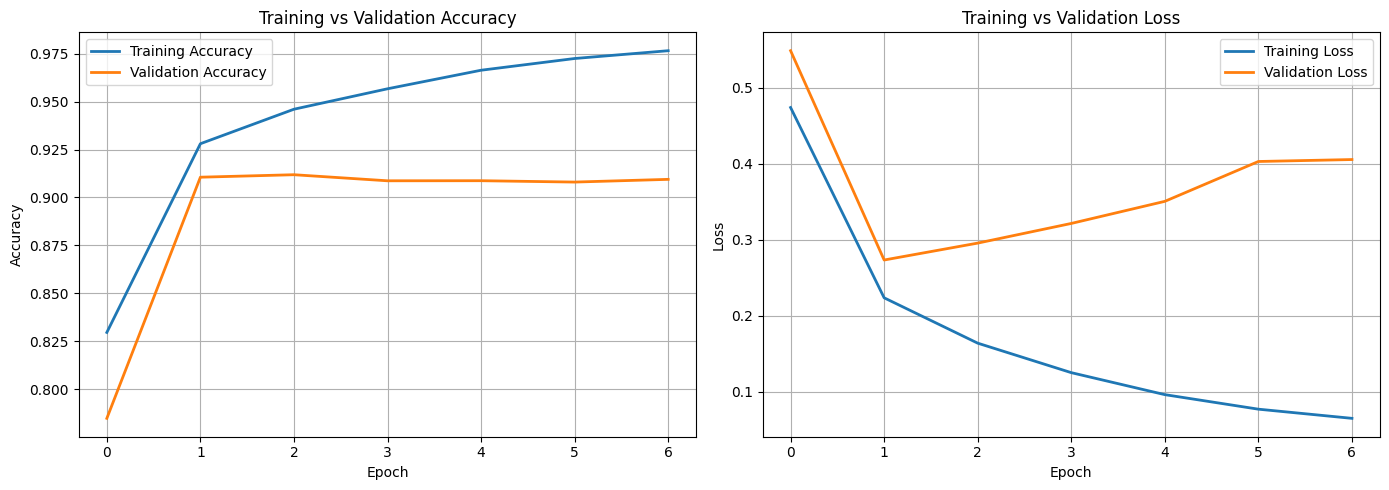

In [22]:
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
# saving the plot
plt.savefig("Accuracy_and_loss_curve.png", dpi=500, bbox_inches="tight")
plt.show()

# Saving Model

In [25]:
import joblib

joblib.dump(vector, "tfidf_vectorizer.pkl")
model.save("ag_news_classifier.keras")